In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from sklearn.neighbors import BallTree

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)

if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2022-el8-x86_64/bin/x86_64-linux/"


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

from cycler import cycler

# Update the default prop_cycle
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap

C0 = LinearSegmentedColormap.from_list(None, ['white', 'C0']); #C0.set_bad(color = 'white')
C1 = LinearSegmentedColormap.from_list(None, ['white', 'C1']); #C1.set_bad(color = 'white')
C2 = LinearSegmentedColormap.from_list(None, ['white', 'C2']); #C2.set_bad(color = 'white')
C3 = LinearSegmentedColormap.from_list(None, ['white', 'C3']); #C3.set_bad(color = 'white')
C4 = LinearSegmentedColormap.from_list(None, ['white', 'C4']); #C4.set_bad(color = 'white')

# Plot ratios

In [3]:
def match_radec_nn(ra1_deg, dec1_deg, ra2_deg, dec2_deg, radius_arcsec):
    """
    For each (ra1,dec1) find the nearest neighbor in catalog 2 within radius_arcsec.
    Returns:
      idx2:  index into catalog2 for each row in catalog1 (=-1 if no match)
      sep_arcsec: separation for each row in catalog1 (np.inf if no match)
    """
    ra1 = np.deg2rad(np.asarray(ra1_deg))
    dec1 = np.deg2rad(np.asarray(dec1_deg))
    ra2 = np.deg2rad(np.asarray(ra2_deg))
    dec2 = np.deg2rad(np.asarray(dec2_deg))

    # BallTree with haversine expects [lat, lon] = [dec, ra]
    cat2 = np.column_stack([dec2, ra2])
    cat1 = np.column_stack([dec1, ra1])

    tree = BallTree(cat2, metric="haversine")

    # query radius in radians
    r = np.deg2rad(radius_arcsec / 3600.0)

    # nearest neighbor (k=1)
    dist_rad, ind = tree.query(cat1, k=1)
    dist_rad = dist_rad[:, 0]
    ind = ind[:, 0]

    # apply radius cut
    ok = dist_rad <= r
    idx2 = np.full(cat1.shape[0], -1, dtype=int)
    sep_arcsec = np.full(cat1.shape[0], np.nan, dtype=float)
    idx2[ok] = ind[ok]
    sep_arcsec[ok] = dist_rad[ok] * (180.0 / np.pi) * 3600.0

    return idx2, sep_arcsec

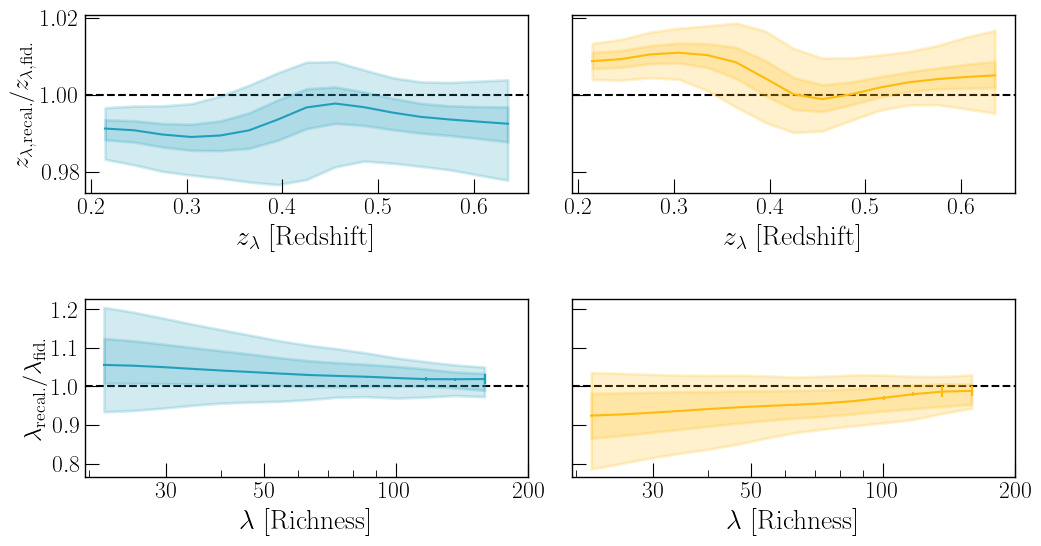

In [8]:
fig, ax = plt.subplots(2, 2, figsize = (12, 6), sharex = 'row', sharey = 'row')
plt.subplots_adjust(wspace = 0.1, hspace = 0.6)

zbins = np.linspace(0.2, 0.65, 15 + 1)
zcen  = (zbins[1:] + zbins[:-1])/2

lbins = np.geomspace(20, 200, 15 + 1)
lcen  = (lbins[1:] + lbins[:-1])/2


decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20250820/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20250918_descalib/Files/my_decade_run_redmapper_v0.8.7_lgt05_vl02_catalog.fit')

ind, sep = match_radec_nn(decade['ra'], decade['dec'], des['ra'], des['dec'], radius_arcsec = 10)
mask = ind > -1

ind_decade     = np.where(mask)[0]
ind_des        = ind[mask]

z_match_decade = decade['z_lambda'][ind_decade]
z_match_des    = des['z_lambda'][ind_des]
l_match_decade = decade['lambda_c'][ind_decade]
l_match_des    = des['lambda_c'][ind_des]

z_unmatch_decade = decade['z_lambda'][np.where(~mask)[0]]
l_unmatch_decade = decade['lambda_c'][np.where(~mask)[0]]


dz    = z_match_des / z_match_decade
res   = [stats.binned_statistic(z_match_decade, dz, statistic = lambda x: np.percentile(x, p), bins = zbins)[0] for
         p in [50, 50 - 68/2, 50 + 68/2, 50 - 95/2, 50 + 95/2, 50 - 99.7/2, 50 + 99.7/2]]
res   = [gaussian_filter1d(r, 1) for r in res]

rinds = [np.random.choice(len(dz), len(dz)) for _ in range(100)]
med   = [stats.binned_statistic(z_match_decade[i], dz[i], statistic = lambda x: np.percentile(x, 50), bins = zbins)[0] for
         i in rinds]
    
ax[0,0].errorbar(zcen, gaussian_filter1d(np.nanmedian(med, axis = 0), 1), yerr = np.nanstd(med, axis = 0), color = 'C1')
ax[0,0].fill_between(zcen, res[1], res[2], alpha = 0.2, color = 'C1', lw = 2)
ax[0,0].fill_between(zcen, res[3], res[4], alpha = 0.2, color = 'C1', lw = 2)


lbins = lbins[:-1]
lcen  = lcen[:-1]

dl    = l_match_des / l_match_decade
res   = [stats.binned_statistic(l_match_decade, dl, statistic = lambda x: np.percentile(x, p), bins = lbins)[0] for
         p in [50, 50 - 68/2, 50 + 68/2, 50 - 95/2, 50 + 95/2, 50 - 99.7/2, 50 + 99.7/2]]
res   = [gaussian_filter1d(r, 1) for r in res]
rinds = [np.random.choice(len(dz), len(dz)) for _ in range(100)]
med   = [stats.binned_statistic(l_match_decade[i], dl[i], statistic = lambda x: np.percentile(x, 50), bins = lbins)[0] for
         i in rinds]

ax[1, 0].errorbar(lcen, gaussian_filter1d(np.nanmedian(med, axis = 0), 1), yerr = np.nanstd(med, axis = 0), color = 'C1')
ax[1, 0].fill_between(lcen, res[1], res[2], alpha = 0.2, color = 'C1', lw = 2)
ax[1, 0].fill_between(lcen, res[3], res[4], alpha = 0.2, color = 'C1', lw = 2)

decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20250828/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20250918_decadecalib/Files/my_decade_run_redmapper_v0.8.7_lgt05_vl02_catalog.fit')

ind, sep = match_radec_nn(decade['ra'], decade['dec'], des['ra'], des['dec'], radius_arcsec = 10)
mask = ind > -1

ind_decade     = np.where(mask)[0]
ind_des        = ind[mask]

z_match_decade = decade['z_lambda'][ind_decade]
z_match_des    = des['z_lambda'][ind_des]
l_match_decade = decade['lambda_c'][ind_decade]
l_match_des    = des['lambda_c'][ind_des]

z_unmatch_decade = decade['z_lambda'][np.where(~mask)[0]]
l_unmatch_decade = decade['lambda_c'][np.where(~mask)[0]]

dz    = z_match_des / z_match_decade
res   = [stats.binned_statistic(z_match_decade, dz, statistic = lambda x: np.percentile(x, p), bins = zbins)[0] for
         p in [50, 50 - 68/2, 50 + 68/2, 50 - 95/2, 50 + 95/2, 50 - 99.7/2, 50 + 99.7/2]]
res   = [gaussian_filter1d(r, 1) for r in res]

rinds = [np.random.choice(len(dz), len(dz)) for _ in range(100)]
med   = [stats.binned_statistic(z_match_decade[i], dz[i], statistic = lambda x: np.percentile(x, 50), bins = zbins)[0] for
         i in rinds]
    
ax[0, 1].errorbar(zcen, gaussian_filter1d(np.nanmedian(med, axis = 0), 1), yerr = np.nanstd(med, axis = 0), color = 'C2')
ax[0, 1].fill_between(zcen, res[1], res[2], alpha = 0.2, color = 'C2', lw = 2)
ax[0, 1].fill_between(zcen, res[3], res[4], alpha = 0.2, color = 'C2', lw = 2)



dl    = l_match_des / l_match_decade
res   = [stats.binned_statistic(l_match_decade, dl, statistic = lambda x: np.percentile(x, p), bins = lbins)[0] for
         p in [50, 50 - 68/2, 50 + 68/2, 50 - 95/2, 50 + 95/2, 50 - 99.7/2, 50 + 99.7/2]]
res   = [gaussian_filter1d(r, 1) for r in res]

rinds = [np.random.choice(len(dz), len(dz)) for _ in range(100)]
med   = [stats.binned_statistic(l_match_decade[i], dl[i], statistic = lambda x: np.percentile(x, 50), bins = lbins)[0] for
         i in rinds]
    
ax[1, 1].errorbar(lcen, gaussian_filter1d(np.nanmedian(med, axis = 0), 1), yerr = np.nanstd(med, axis = 0), color = 'C2')
ax[1, 1].fill_between(lcen, res[1], res[2], alpha = 0.2, color = 'C2', lw = 2)
ax[1, 1].fill_between(lcen, res[3], res[4], alpha = 0.2, color = 'C2', lw = 2)
ax[1, 1].set_xscale('log')

[a.axhline(1, color = 'k', ls = '--', zorder = -1000) for a in ax[0]]
[a.axhline(1, color = 'k', ls = '--', zorder = -1000) for a in ax[1]]

ax[1, 0].set_yticks([1.2, 1.1, 1.0, 0.9, 0.8])
ax[1, 0].set_xticks([30, 50, 100, 200])
ax[1, 0].set_xticklabels([30, 50, 100, 200])

ax[0, 0].set_ylabel(r'$z_{\lambda, \rm recal.} / z_{\lambda, \rm fid.}$', size = 18)
ax[1, 0].set_ylabel(r'$\lambda_{\rm recal.} / \lambda_{\rm fid.}$', size = 18)

[a.set_xlabel(r'$z_\lambda$ [Redshift]', size = 20) for a in ax[0]]
[a.set_xlabel(r'$\lambda$ [Richness]',   size = 20) for a in ax[1]]

plt.savefig('./DECADEvsDES.pdf', dpi = 300)
plt.show()

# Plot summaries

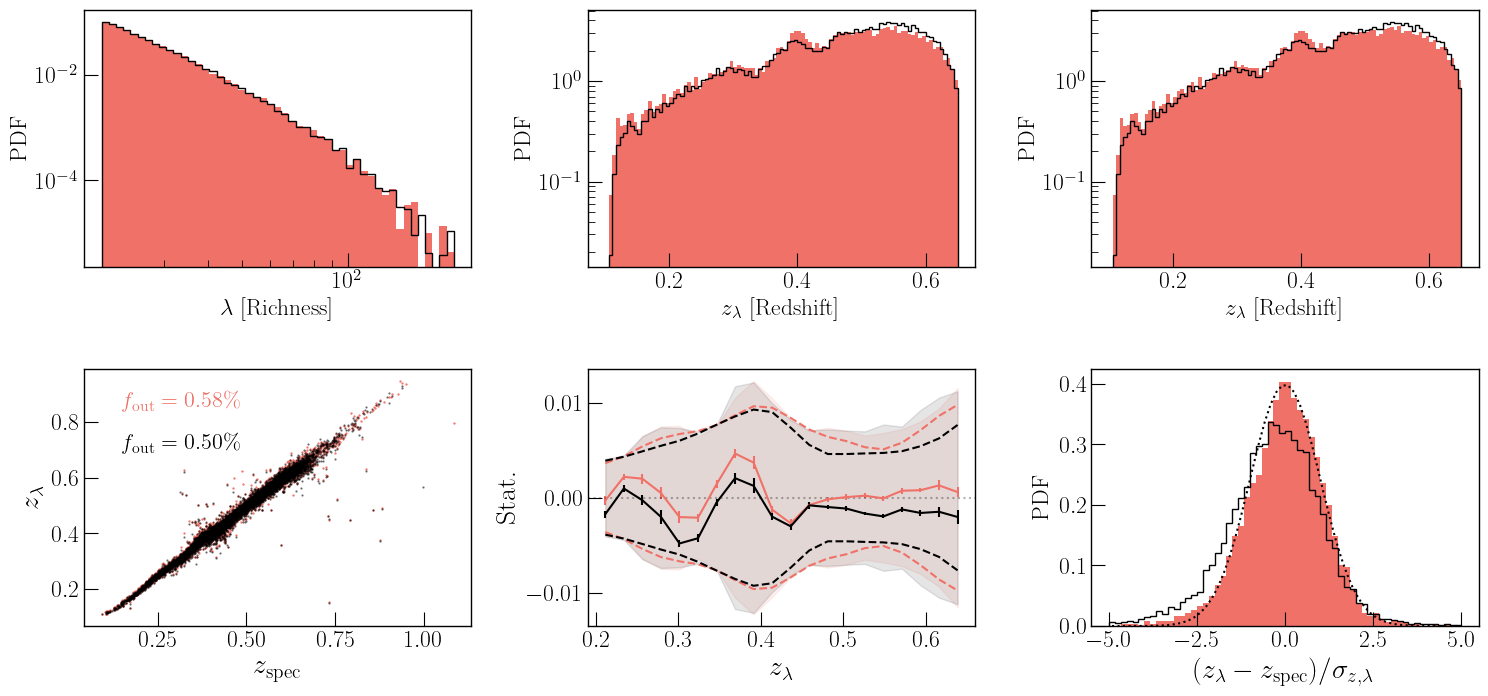

In [107]:
decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20250820/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADE_20250918_descalib/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')

fig, ax = plt.subplots(2, 3, figsize = (18, 8))
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
aflat   = ax.flat
bins = np.geomspace(20, 200, 50)
clrs = aflat[0].hist(decade['lambda_c'], bins = bins, density = True, log = True, label = 'DECADE')
aflat[0].hist(des['lambda_c'], bins = bins, histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[0].set_xlabel(r'$\lambda$ [Richness]', size = 17)
aflat[0].set_ylabel('PDF', size = 17)
aflat[0].set_xscale('log')

clrs = aflat[1].hist(decade['z_lambda'], bins = np.linspace(0.1, 0.65, 100), density = True, log = True, label = 'DECADE')
aflat[1].hist(des['z_lambda'], bins = clrs[1], histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[1].set_xlabel(r'$z_\lambda$ [Redshift]', size = 17)
aflat[1].set_ylabel('PDF', size = 17)


clrs = aflat[2].hist(decade['z_lambda'], bins = np.linspace(0.1, 0.65, 100), density = True, log = True, label = 'DECADE')
aflat[2].hist(des['z_lambda'], bins = clrs[1], histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[2].set_xlabel(r'$z_\lambda$ [Redshift]', size = 17)
aflat[2].set_ylabel('PDF', size = 17)

msk = decade['cg_spec_z'] > -1
clrs = aflat[3].scatter(decade['cg_spec_z'][msk], decade['z_lambda'][msk], s = 0.4)
eta  = np.average((np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'])[msk] > 0.15) 
aflat[3].text(0.15, 0.85, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'C0')

msk = des['cg_spec_z'] > -1
eta  = np.average((np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'])[msk] > 0.15)
aflat[3].text(0.15, 0.70, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'k')

aflat[3].scatter(des['cg_spec_z'][msk], des['z_lambda'][msk], s = 0.4, color = 'k', alpha = 0.5);
aflat[3].set_xlabel(r'$z_{\rm spec}$', size = 20)
aflat[3].set_ylabel(r'$z_{\lambda}$', size = 20)


zbs = np.linspace(0.2, 0.65, 20 + 1)
zcn = (zbs[1:] + zbs[:-1])/2

msk = decade['cg_spec_z'] > -1
msk = msk & (np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'] < 0.15)
z   = decade['z_lambda'][msk]
dz  = (decade['z_lambda'][msk] - decade['cg_spec_z'][msk]) / (1 + decade['z_lambda'][msk])
sz  = decade['z_lambda_e'][msk] / (1 + decade['z_lambda'][msk])

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'C0')
aflat[4].fill_between(zcn, -np.median(std, axis = 0), np.median(std, axis = 0), color = 'C0', alpha = 0.1)
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'C0', ls = '--')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'C0', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'C0')

msk = des['cg_spec_z'] > -1
msk = msk & (np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'] < 0.15)
z   = des['z_lambda'][msk]
dz  = (des['z_lambda'][msk] - des['cg_spec_z'][msk]) / (1 + des['z_lambda'][msk])
sz  = des['z_lambda_e'][msk] / (1 + des['z_lambda'][msk])

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'k')
aflat[4].fill_between(zcn, -np.median(std, axis = 0), np.median(std, axis = 0), color = 'k', alpha = 0.1)
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'k', ls = '--')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'k', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'k')

aflat[4].axhline(0, color = 'k', ls = ':', alpha = 0.3)
aflat[4].set_xlabel(r'$z_{\lambda}$', size = 20)
aflat[4].set_ylabel(r'Stat.', size = 20)



msk = decade['cg_spec_z'] > -1
sig = (decade['z_lambda'] - decade['cg_spec_z'])/decade['z_lambda_e']
clrs = aflat[5].hist(sig[msk], bins = 60, density = True, range = (-5, 5))

msk = des['cg_spec_z'] > -1
sig = (des['z_lambda'] - des['cg_spec_z'])/des['z_lambda_e']
aflat[5].hist(sig[msk], bins = clrs[1], density = True, color = 'k', histtype = 'step')
aflat[5].set_xlabel(r'$(z_{\rm \lambda} - z_{\rm spec}) / \sigma_{z, {\lambda}}$', size = 20)
aflat[5].set_ylabel(r'PDF', size = 17)

cen   = (clrs[1][1:] + clrs[1][:-1])/2
gauss = 1/np.sqrt(2 * np.pi) * np.exp(-np.power(cen, 2)/2)
aflat[5].plot(cen, gauss, color = 'k', ls = ':')


plt.show()

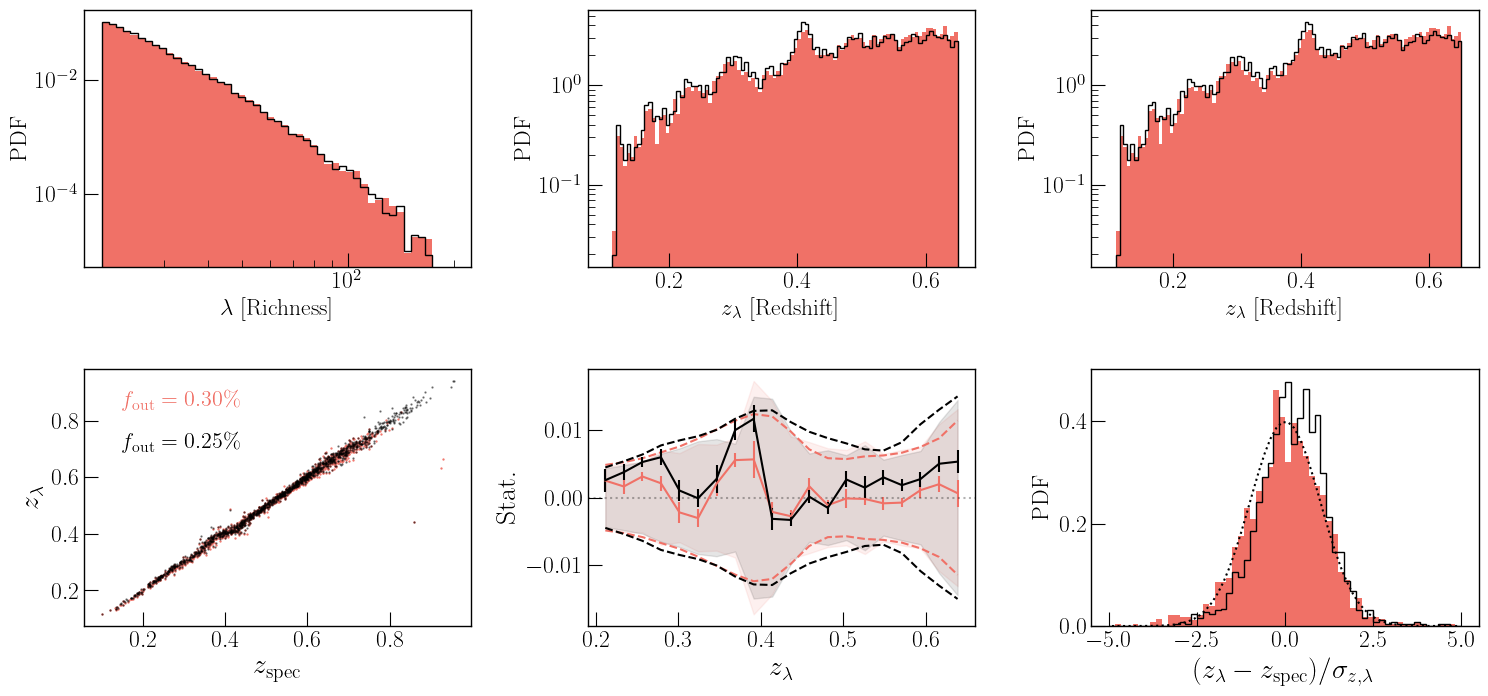

In [7]:
decade = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20250828/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
des    = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DES_20250918_decadecalib/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')

fig, ax = plt.subplots(2, 3, figsize = (18, 8))
plt.subplots_adjust(hspace = 0.4, wspace = 0.3)
aflat   = ax.flat
bins = np.geomspace(20, 200, 50)
clrs = aflat[0].hist(decade['lambda_c'], bins = bins, density = True, log = True, label = 'DECADE')
aflat[0].hist(des['lambda_c'], bins = bins, histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[0].set_xlabel(r'$\lambda$ [Richness]', size = 17)
aflat[0].set_ylabel('PDF', size = 17)
aflat[0].set_xscale('log')

clrs = aflat[1].hist(decade['z_lambda'], bins = np.linspace(0.1, 0.65, 100), density = True, log = True, label = 'DECADE')
aflat[1].hist(des['z_lambda'], bins = clrs[1], histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[1].set_xlabel(r'$z_\lambda$ [Redshift]', size = 17)
aflat[1].set_ylabel('PDF', size = 17)


clrs = aflat[2].hist(decade['z_lambda'], bins = np.linspace(0.1, 0.65, 100), density = True, log = True, label = 'DECADE')
aflat[2].hist(des['z_lambda'], bins = clrs[1], histtype = 'step', color = 'k', density = True, log = True, label = 'DES');
aflat[2].set_xlabel(r'$z_\lambda$ [Redshift]', size = 17)
aflat[2].set_ylabel('PDF', size = 17)

msk = decade['cg_spec_z'] > -1
clrs = aflat[3].scatter(decade['cg_spec_z'][msk], decade['z_lambda'][msk], s = 0.4)
eta  = np.average((np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'])[msk] > 0.15) 
aflat[3].text(0.15, 0.85, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'C0')

msk = des['cg_spec_z'] > -1
eta  = np.average((np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'])[msk] > 0.15)
aflat[3].text(0.15, 0.70, fr'$f_{{\rm out}} = {eta * 100:0.2f}\%$', size = 16, color = 'k')

aflat[3].scatter(des['cg_spec_z'][msk], des['z_lambda'][msk], s = 0.4, color = 'k', alpha = 0.5);
aflat[3].set_xlabel(r'$z_{\rm spec}$', size = 20)
aflat[3].set_ylabel(r'$z_{\lambda}$', size = 20)


zbs = np.linspace(0.2, 0.65, 20 + 1)
zcn = (zbs[1:] + zbs[:-1])/2

msk = decade['cg_spec_z'] > -1
msk = msk & (np.abs(decade['z_lambda'] - decade['cg_spec_z']) / decade['cg_spec_z'] < 0.15)
z   = decade['z_lambda'][msk]
dz  = decade['z_lambda'][msk] - decade['cg_spec_z'][msk]
sz  = decade['z_lambda_e'][msk]

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'C0')
aflat[4].fill_between(zcn, -np.median(std, axis = 0), np.median(std, axis = 0), color = 'C0', alpha = 0.1)
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'C0', ls = '--')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'C0', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'C0')

msk = des['cg_spec_z'] > -1
msk = msk & (np.abs(des['z_lambda'] - des['cg_spec_z']) / des['cg_spec_z'] < 0.15)
z   = des['z_lambda'][msk]
dz  = des['z_lambda'][msk] - des['cg_spec_z'][msk]
sz  = des['z_lambda_e'][msk]

ind = [np.random.choice(len(z), len(z)) for _ in range(100)]
med = [stats.binned_statistic(z[m], dz[m], statistic = 'median', bins = zbs)[0] for m in ind]
avg = [stats.binned_statistic(z[m], dz[m], statistic = 'mean',   bins = zbs)[0] for m in ind]
std = [stats.binned_statistic(z[m], dz[m], statistic = 'std',    bins = zbs)[0] for m in ind]
err = [stats.binned_statistic(z[m], sz[m], statistic = 'median', bins = zbs)[0] for m in ind]

aflat[4].errorbar(zcn, np.median(med, axis = 0), yerr = np.std(med, axis = 0), color = 'k')
aflat[4].fill_between(zcn, -np.median(std, axis = 0), np.median(std, axis = 0), color = 'k', alpha = 0.1)
aflat[4].plot(zcn, np.median(err, axis = 0), color = 'k', ls = '--')
aflat[4].plot(zcn, -np.median(err, axis = 0), color = 'k', ls = '--')
# aflat[4].errorbar(zcn + 0.05, np.median(avg, axis = 0), yerr = np.std(avg, axis = 0), color = 'k')

aflat[4].axhline(0, color = 'k', ls = ':', alpha = 0.3)
aflat[4].set_xlabel(r'$z_{\lambda}$', size = 20)
aflat[4].set_ylabel(r'Stat.', size = 20)



msk = decade['cg_spec_z'] > -1
sig = (decade['z_lambda'] - decade['cg_spec_z'])/decade['z_lambda_e']
clrs = aflat[5].hist(sig[msk], bins = 60, density = True, range = (-5, 5))

msk = des['cg_spec_z'] > -1
sig = (des['z_lambda'] - des['cg_spec_z'])/des['z_lambda_e']
aflat[5].hist(sig[msk], bins = clrs[1], density = True, color = 'k', histtype = 'step')
aflat[5].set_xlabel(r'$(z_{\rm \lambda} - z_{\rm spec}) / \sigma_{z, {\lambda}}$', size = 20)
aflat[5].set_ylabel(r'PDF', size = 17)

cen   = (clrs[1][1:] + clrs[1][:-1])/2
gauss = 1/np.sqrt(2 * np.pi) * np.exp(-np.power(cen, 2)/2)
aflat[5].plot(cen, gauss, color = 'k', ls = ':')


plt.show()